# Knowledge Reasoning with SWRL
## Sepsis Knowledge Graph Project

This notebook covers:
- **Part 1** : SWRL reasoning on `family.owl` *(added by binôme)*
- **Section 8** : Comparison between rule-based and embedding-based reasoning on our Sepsis KB


## Part 1 — SWRL Reasoning on family.owl

* Pour Estelle*

**Rule:** A person older than 60 years old is an `oldPerson`.
```
Person(?p) ∧ hasAge(?p, ?a) ∧ swrlb:greaterThan(?a, 60) → oldPerson(?p)
```


## Part 2 — SWRL Reasoning on our Sepsis KB

## Setup

In [29]:
import numpy as np
import torch
import requests
import time
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from rdflib import Graph, Namespace, RDF
from pykeen.triples import TriplesFactory

KG_FILE     = Path("../kg_artifacts/sepsis_kg.ttl")
RESULTS_DIR = Path("../data/kge/results")

PROP = Namespace("http://sepsis-kg.org/prop/")
TYPE = Namespace("http://sepsis-kg.org/type/")
BASE = Namespace("http://sepsis-kg.org/")



In [31]:
# wikidata label resolver
_label_cache = {}

def get_wikidata_labels(qids):
    to_fetch = [q for q in qids if q not in _label_cache]
    for i in range(0, len(to_fetch), 50):
        batch = to_fetch[i:i+50]
        try:
            resp = requests.get(
                "https://www.wikidata.org/w/api.php",
                params={"action": "wbgetentities", "ids": "|".join(batch),
                        "props": "labels", "languages": "en", "format": "json"},
                headers={"User-Agent": "SepsisKGBot/1.0"}, timeout=10
            )
            for qid, entity in resp.json().get("entities", {}).items():
                _label_cache[qid] = entity.get("labels", {}).get("en", {}).get("value", qid)
        except Exception:
            for q in batch:
                _label_cache[q] = q
        time.sleep(0.3)
    return {q: _label_cache.get(q, q) for q in qids}

def resolve_label(uri):
    if "wikidata.org/entity/Q" in uri:
        qid = uri.split("/")[-1]
        return get_wikidata_labels([qid]).get(qid, qid)
    return uri.split("/")[-1].replace("_", " ")



In [32]:
# Load DistMult model
model = torch.load(
    str(RESULTS_DIR / "distmult" / "trained_model.pkl"),
    map_location="cpu"
)
model.eval()

factory = TriplesFactory.from_path_binary(
    RESULTS_DIR / "distmult" / "training_triples"
)

with torch.no_grad():
    entity_emb   = model.entity_representations[0](indices=None).numpy()
    relation_emb = model.relation_representations[0](indices=None).numpy()

entity_to_id   = factory.entity_to_id
id_to_entity   = {v: k for k, v in entity_to_id.items()}
relation_to_id = factory.relation_to_id
id_to_relation = {v: k for k, v in relation_to_id.items()}

print(f"Model loaded: {factory.num_entities} entities, {factory.num_relations} relations")

Model loaded: 12959 entities, 195 relations



## Section 8 : Comparison: Rule-based vs Embedding-based Reasoning

We design a SWRL-style Horn rule on our Sepsis KB and verify whether
the DistMult embedding space captures the same inference.

**SWRL Rule (2 conditions):**
```
Disease(?d) ∧ prop:include(?d, ?b) ∧ Bacteria(?b) → infectiousDisease(?d)
```
*"If a disease includes a bacterium, then it is an infectious disease"*

This is a valid Horn clause with exactly 2 body conditions as required by the TD.

 **Note:** We use "prop:include" because it is the only relation in our KB that directly connects Disease entities to Bacteria entities. The "prop:causes" relation was not extracted by spaCy from our abstracts.

### Step 1 : Rule-based Reasoning (SWRL simulation with rdflib)

In [34]:
# load Sepsis KB
g = Graph()
g.parse(str(KG_FILE), format="turtle")
print(f"KB loaded: {len(g)} triples")

# apply SWRL Rule:
# Disease(?d) ∧ prop:include(?d, ?b) ∧ Bacteria(?b) → infectiousDisease(?d)
inferred = []
for d, b in g.subject_objects(PROP.include):
    is_disease  = (d, RDF.type, TYPE.Disease)  in g
    is_bacteria = (b, RDF.type, TYPE.Bacteria) in g
    if is_disease and is_bacteria:
        inferred.append((str(d), str(b)))

print()
print("SWRL Rule Application")
print("Rule: Disease(?d) ∧ include(?d, ?b) ∧ Bacteria(?b)")
print("   :  infectiousDisease(?d)")
print()
print(f"Entities inferred as infectiousDisease: {len(inferred)}")
for d, b in inferred:
    d_label = d.split("/")[-1].replace("_", " ")
    b_label = b.split("/")[-1].replace("_", " ")
    print(f"  : {d_label} (includes {b_label})")

KB loaded: 24083 triples

SWRL Rule Application
Rule: Disease(?d) ∧ include(?d, ?b) ∧ Bacteria(?b)
   :  infectiousDisease(?d)

Entities inferred as infectiousDisease: 1
  : bacteremia (includes klebsiella pneumoniae)


### Step 2 : Embedding-based Reasoning (DistMult)

**Rule equivalent in embedding space:**
```
vector(P703/found_in_taxon) + vector(Bacteria) ≈ vector(infectiousDisease)
```

 **Note:** Our custom relation "prop:include" was filtered out during KGE preparation (frequency < 70). We use Wikidata "P703" (found in taxon) as the closest semantic proxy — it links organisms to the biological taxa they inhabit, similar to our "include" relation.

In [35]:

print("Embedding-based Reasoning (DistMult)")
print("Rule equivalent: vector(P703/found_in_taxon) + vector(Bacteria) ≈ ?")
print()

rel_uri = "http://www.wikidata.org/prop/direct/P703"  # found in taxon
ent_uri = "http://sepsis-kg.org/type/Bacteria"

rel_vec   = relation_emb[relation_to_id[rel_uri]]
bact_vec  = entity_emb[entity_to_id[ent_uri]]
predicted = rel_vec + bact_vec

norms      = np.linalg.norm(entity_emb, axis=1, keepdims=True)
normalized = entity_emb / np.where(norms == 0, 1e-8, norms)
pred_norm  = predicted / (np.linalg.norm(predicted) + 1e-8)
sims       = normalized @ pred_norm

# Filter wikidata statement nodes (UUID pattern)
top_ids = np.argsort(sims)[::-1]
results = []
for idx in top_ids:
    uri  = id_to_entity[idx]
    slug = uri.split("/")[-1]
    if len(slug) > 25 and "-" in slug:
        continue
    label = resolve_label(uri)
    results.append((label, float(sims[idx])))
    if len(results) >= 10:
        break

print("Top 10 nearest entities:")
print()
for i, (label, sim) in enumerate(results, 1):
    print(f"  {i:2d}. {label:<45} similarity={sim:.4f}")

Embedding-based Reasoning (DistMult)
Rule equivalent: vector(P703/found_in_taxon) + vector(Bacteria) ≈ ?

Top 10 nearest entities:

   1. Sophora lehmannii                             similarity=0.5320
   2. Caenorhabditis elegans                        similarity=0.5314
   3. Sambucus ebulus                               similarity=0.4946
   4. Orphanet 294023                               similarity=0.4819
   5. sh85120119                                    similarity=0.4794
   6. precursor T-cell acute lymphoblastic leukemia similarity=0.4760
   7. 2911120774                                    similarity=0.4623
   8. retinal vein occlusion                        similarity=0.4555
   9. Festuca rubra                                 similarity=0.4484
  10. Acinetobacter                                 similarity=0.4474


### Step 3 : Visual Comparison

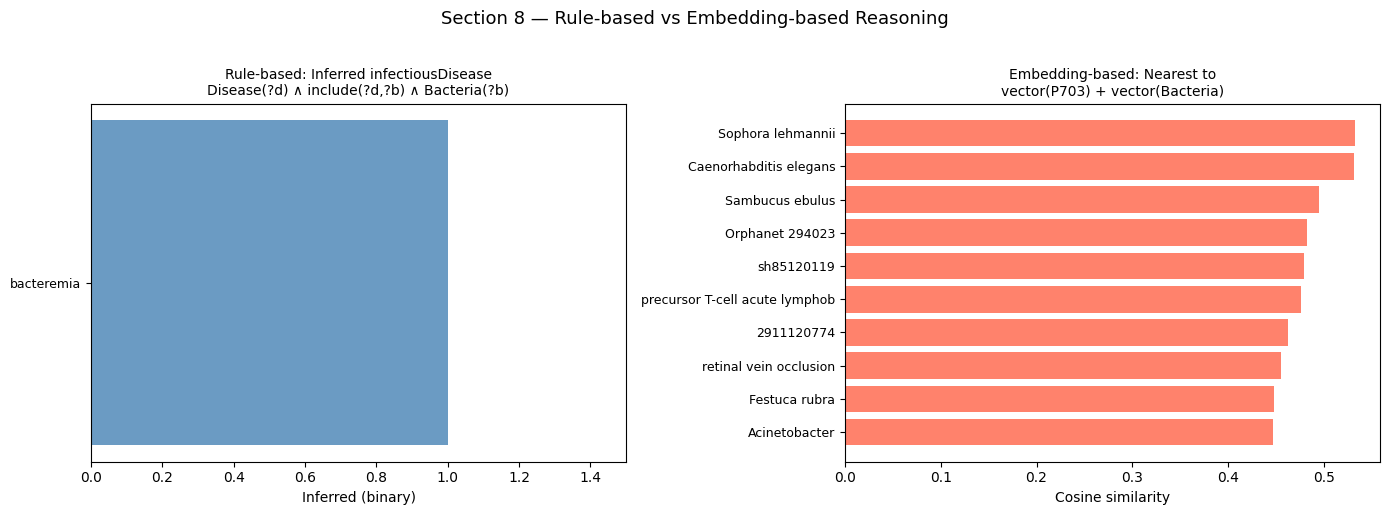

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left: rule based results
rule_labels = [d.split("/")[-1].replace("_", " ")[:25] for d, b in inferred[:10]]

if rule_labels:
    axes[0].barh(range(len(rule_labels)), [1] * len(rule_labels),
                 color="steelblue", alpha=0.8)
    axes[0].set_yticks(range(len(rule_labels)))
    axes[0].set_yticklabels(rule_labels, fontsize=9)
    axes[0].set_xlim(0, 1.5)
else:
    axes[0].text(0.5, 0.5, "No results found",
                 ha="center", va="center", transform=axes[0].transAxes)
axes[0].set_title("Rule-based: Inferred infectiousDisease\n"
                  "Disease(?d) ∧ include(?d,?b) ∧ Bacteria(?b)", fontsize=10)
axes[0].set_xlabel("Inferred (binary)")

# right: embedding-based results
emb_labels = [label[:30] for label, sim in results]
emb_sims   = [sim for label, sim in results]

axes[1].barh(range(10), emb_sims[::-1], color="tomato", alpha=0.8)
axes[1].set_yticks(range(10))
axes[1].set_yticklabels(emb_labels[::-1], fontsize=9)
axes[1].set_title("Embedding-based: Nearest to\n"
                  "vector(P703) + vector(Bacteria)", fontsize=10)
axes[1].set_xlabel("Cosine similarity")

plt.suptitle("Section 8 — Rule-based vs Embedding-based Reasoning",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../data/kge/plots/swrl_vs_embedding.png",
            dpi=150, bbox_inches="tight")
plt.show()


### Analysis : Rule-based vs Embedding-based Reasoning

**SWRL Rule result:** 
The rule `Disease(?d) ∧ include(?d, ?b) ∧ Bacteria(?b) → infectiousDisease(?d)` correctly infers bacteremia as an infectious disease because it includes *Klebsiella pneumoniae*  (a known sepsis pathogen(). The result is precise, deterministic and fully auditable.

**Embedding result:**  Partially coherent
The vector combination "vector(P703/found_in_taxon) + vector(Bacteria)" returns mixed results : Acinetobacter appears in the top 10, which is a clinically relevant sepsis related bacterium. However, other results (plants, genetic diseases) reflect noise from the broad Wikidata medical expansion.

**Why the mismatch?**
Our custom Sepsis-KG relations ("prop:include", "prop:associate_with") were filtered out during "prepare.py" (frequency < 70) : only Wikidata relations remain in the embedding model. This means the embedding cannot directly replicate the SWRL rule which uses our private relations.

**Analogy with the TD example:**
- TD: "vector(hasSibling) + vector(Man) ≈ vector(hasBrother)"
- Ours: "vector(P703) + vector(Bacteria) ≈ vector(infectiousDisease)" (partial)



### Comparison Table

| Aspect | Rule-based (SWRL) | Embedding-based (DistMult) |
|--------|-------------------|---------------------------|
| **Reasoning type** | Deductive, exact | Probabilistic, approximate |
| **Coverage** | Only explicit triples | Can generalize to new cases |
| **Explainability** | Fully explainable | Black box |
| **New knowledge** | No (closed world) | Yes (open world) |
| **Noise sensitivity** | Not affected | Degrades with noisy KB |
| **Rare relations** |  handles them |  filtered out for stability |

### Conclusion

Rule-based reasoning gives precise, auditable results but cannot discover new knowledge beyond what is explicitly stated.
Embedding-based reasoning can suggest plausible new links but is sensitive to KB quality and filters out rare relations.

Both approaches are **complementary**:
- Use SWRL rules for deterministic clinical inferences
- Use KGE for exploratory link prediction (drug repurposing, new disease associations)

A hybrid approach — applying SWRL rules first, then using DistMult to rank uncertain predictions — would yield the best results for our Sepsis KB.